## Linear Auto-Encoder on MNIST

In [1]:
import numpy as np 
import torch, os, pickle, torchvision
import matplotlib.pyplot as plt 
from torchvision import transforms 
%matplotlib inline

In [2]:
# defining hyperparameters

n_epochs = 100
batch_size_train = 64
batch_size_test = 1000 
learning_rate = 1e-2
log_interval = 100 

random_seed = 1
torch.manual_seed(random_seed) 

# determine if CUDA is available 
if torch.cuda.is_available():
    device = 'cuda'
    print('GPU available')
else:
    device = 'cpu'
    print('only CPU available')

GPU available


In [3]:
resultsPath = os.path.join('results', '4_AE_linear')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath) 

In [4]:
# defining training data and data loader
train_data = torchvision.datasets.MNIST(
    root = 'data',
    train=True,
    download=False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = (0.1307,),
            std = (0.3081,)
        )
    ])
)
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size_train)

In [5]:
# defining testing data and data loader
test_data = torchvision.datasets.MNIST(
    root = 'data',
    train=False,
    download=False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean = (0.1307, ),
            std = (0.3081, )
        )
    ])
)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size_test) 

In [6]:
len(train_dataloader.dataset)

60000

In [7]:
train_feature, train_label = next(iter(train_dataloader))

In [8]:
train_feature.shape

torch.Size([64, 1, 28, 28])

In [9]:
test_feature, test_label = next(iter(test_dataloader))

In [10]:
test_feature.shape 

torch.Size([1000, 1, 28, 28])

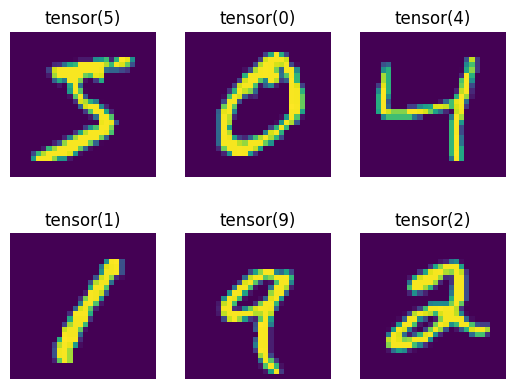

In [11]:
fig = plt.figure() 

for i in np.arange(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(train_feature[i].squeeze())
    plt.title(train_label[i])
    plt.axis('off')

In [12]:
import torch.nn.functional as F

In [13]:
class AutoEncoder_Linear(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dense1 = torch.nn.Linear(in_features=28*28, out_features=1000, bias=True, device=device)
        self.dense2 = torch.nn.Linear(in_features=1000, out_features=28*28, bias=True, device=device)

    def forward(self, input):
        d1 = F.relu(self.dense1(input.reshape(input.shape[0], -1))) 
        # d1 = self.dense1(input.reshape(input.shape[0], -1))
        # print(f'd1 shape: {d1.shape}')
        output = F.relu(self.dense2(d1))
        # output = self.dense2(d1)
        # print(f'output shape: {output.shape}')
        return output 

In [14]:
auto_encoder = AutoEncoder_Linear()
print(auto_encoder)

AutoEncoder_Linear(
  (dense1): Linear(in_features=784, out_features=1000, bias=True)
  (dense2): Linear(in_features=1000, out_features=784, bias=True)
)


In [15]:
auto_encoder = AutoEncoder_Linear().to(device)
optimizer = torch.optim.SGD(params=auto_encoder.parameters(), lr=learning_rate)

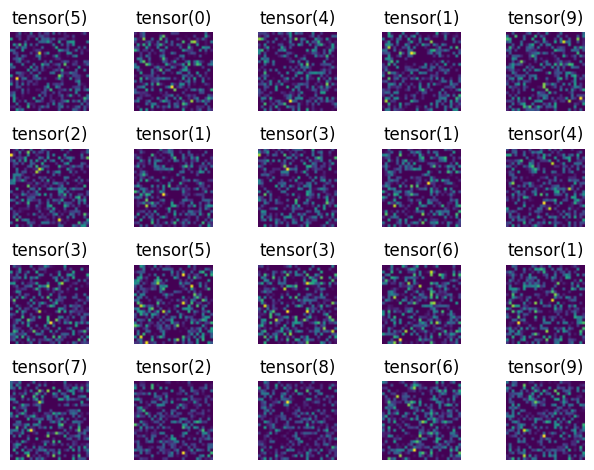

In [16]:
# before training, the auto-encoder should not be able to encode the images 
output = auto_encoder(train_feature.to(device))
output = output.reshape(output.shape[0], 28, 28) 

for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(output[i].detach().cpu().numpy())
    plt.title(train_label[i])
    plt.axis('off')
plt.tight_layout()

In [17]:
train_losses = []
test_losses = []
train_steps = []
test_steps = [i * len(train_dataloader.dataset) for i in np.arange(n_epochs+1)] 

In [18]:
def train(epoch):
    auto_encoder.train()
    for batch_id, (train_features, train_labels) in enumerate(train_dataloader):
        train_features, train_labels = train_features.to(device), train_labels.to(device)
        optimizer.zero_grad() 
        output = auto_encoder(train_features)
        loss = F.mse_loss(output, train_features.reshape(train_features.shape[0], -1)) 
        loss.backward()
        optimizer.step() 

        if np.mod(batch_id, log_interval) == 0:
            train_losses.append(loss.item())
            train_steps.append(batch_id * batch_size_train + epoch * len(train_dataloader.dataset))

            print(f'Epoch {epoch}: {batch_id*batch_size_train}/{len(train_dataloader.dataset)},  train loss: {train_losses[-1]}')

In [19]:
def test():
    auto_encoder.eval()
    test_loss = 0 
    with torch.no_grad():
        for test_features, test_labels in test_dataloader:
            test_features, test_labels = test_features.to(device), test_labels.to(device)
            output = auto_encoder(test_features)
            test_loss += F.mse_loss(output, test_features.reshape(test_features.shape[0], -1)).item() 

        test_loss /= len(test_dataloader) 
        test_losses.append(test_loss)
       
    print(f'test set avg loss: {test_loss}')

In [20]:
test()

for epoch in np.arange(n_epochs):
    train(epoch)
    test()

test set avg loss: 1.0386118650436402
Epoch 0: 0/60000,  train loss: 0.9949329495429993
Epoch 0: 6400/60000,  train loss: 0.9970436692237854
Epoch 0: 12800/60000,  train loss: 0.7945810556411743
Epoch 0: 19200/60000,  train loss: 0.9294682741165161
Epoch 0: 25600/60000,  train loss: 0.7896466851234436
Epoch 0: 32000/60000,  train loss: 0.7715843319892883
Epoch 0: 38400/60000,  train loss: 0.7250752449035645
Epoch 0: 44800/60000,  train loss: 0.6989574432373047
Epoch 0: 51200/60000,  train loss: 0.7661309242248535
Epoch 0: 57600/60000,  train loss: 0.6907966732978821
test set avg loss: 0.6954477250576019
Epoch 1: 0/60000,  train loss: 0.664240300655365
Epoch 1: 6400/60000,  train loss: 0.6953791975975037
Epoch 1: 12800/60000,  train loss: 0.6262946724891663
Epoch 1: 19200/60000,  train loss: 0.7016236782073975
Epoch 1: 25600/60000,  train loss: 0.6436955332756042
Epoch 1: 32000/60000,  train loss: 0.6272923350334167
Epoch 1: 38400/60000,  train loss: 0.5955533385276794
Epoch 1: 44800/60

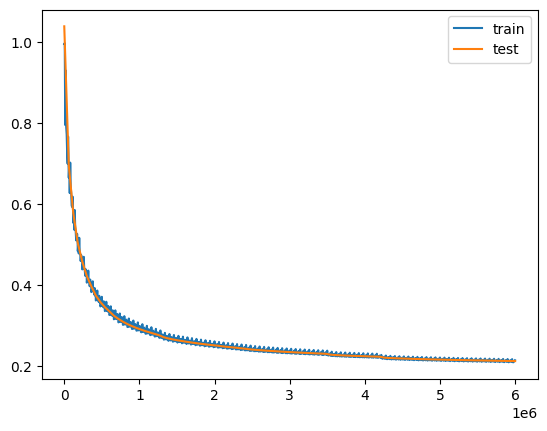

In [21]:
plt.figure()

plt.plot(train_steps, train_losses)
plt.plot(test_steps, test_losses)
plt.legend(['train', 'test']) 

In [22]:
train_data, train_labels = next(iter(train_dataloader)) 

In [23]:
output = auto_encoder(train_data.to(device)) 
output = output.reshape(output.shape[0], 28, 28)

In [24]:
output.shape 

torch.Size([64, 28, 28])

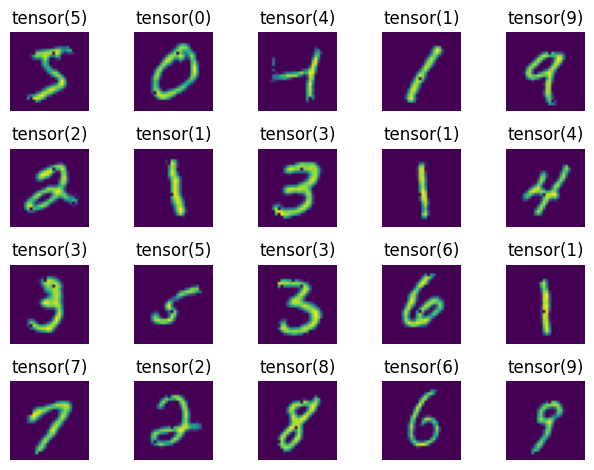

In [25]:
for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(output[i].detach().cpu().numpy())
    plt.title(train_labels[i])
    plt.axis('off')
plt.tight_layout()